# Imports

In [ ]:
import math
import numpy as np
import pandas as pd
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Seed

In [ ]:
SEED=139
np.random.seed(SEED)

# Dataset

In [ ]:
dataset = pd.read_csv('dataset/Unlabelled_dataset.csv')
print(dataset.columns)

Index(['f1', 'f2', 'f3', 'f4', 'f5'], dtype='object')


In [ ]:
X = dataset[['f1', 'f2', 'f3', 'f4']].dropna().to_numpy()
X = StandardScaler().fit_transform(X)

# Finding Optimal K

In [ ]:
def run(k):
    model = KMeans(k, random_state=SEED)
    model.fit(X)
    
    return model.inertia_, silhouette_score(X, model.predict(X))

## Plotting K vs Metrics

In [ ]:
def plot_k_vs_inertia():
    ks = list(range(2, 11))
    inertias = []
    for k in ks:
        inertia, _ = run(k)
        inertias.append(inertia)
        
    plt.title(f'K vs Inertia')
    plt.plot(ks, inertias)
    plt.xlabel('Cluster Count (K)')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()
    
    kl = KneeLocator(
        x=ks, y=inertias, curve="convex", direction="decreasing"
    )

    print(f"The optimal number of clusters (elbow) is: {kl.elbow}")

c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib

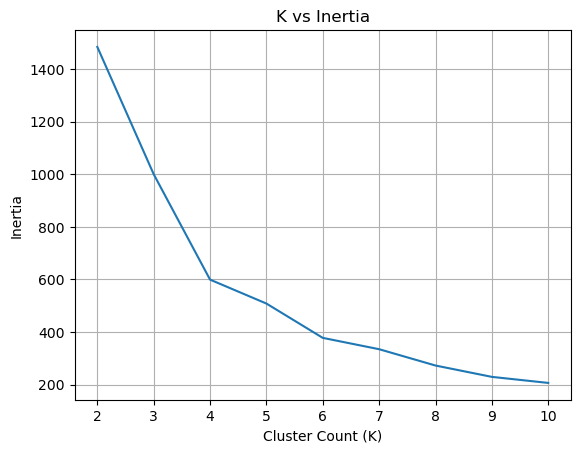

The optimal number of clusters (elbow) is: 4


In [ ]:
plot_k_vs_inertia()

In [ ]:
def plot_k_vs_sil_score():
    ks = list(range(2, 11))
    sil_scores = []
    
    best_sil_score = -math.inf
    best_k = None
    for k in ks:
        _, sil_score = run(k)
        if sil_score > best_sil_score:
            best_sil_score = sil_score
            best_k = k
        sil_scores.append(sil_score)
        
    plt.title(f'K vs Inertia')
    plt.plot(ks, sil_scores)
    plt.xlabel('Cluster Count (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    print(f"The optimal number of clusters is: {best_k}, with silhouette score: {best_sil_score}")

c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib

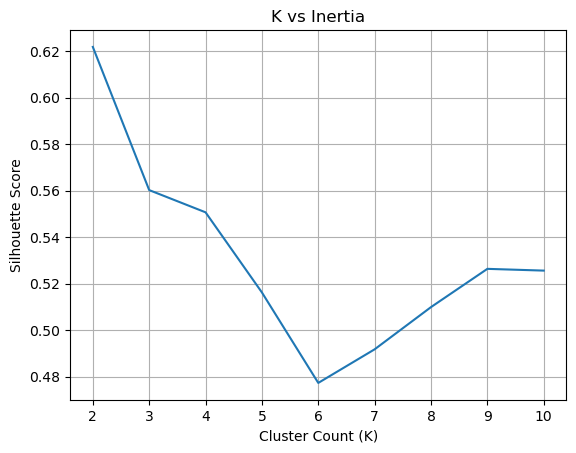

The optimal number of clusters is: 2, with silhouette score: 0.6218827740144827


In [ ]:
plot_k_vs_sil_score()

Text(0.5, 1.0, 'PCA Scatter Chart')

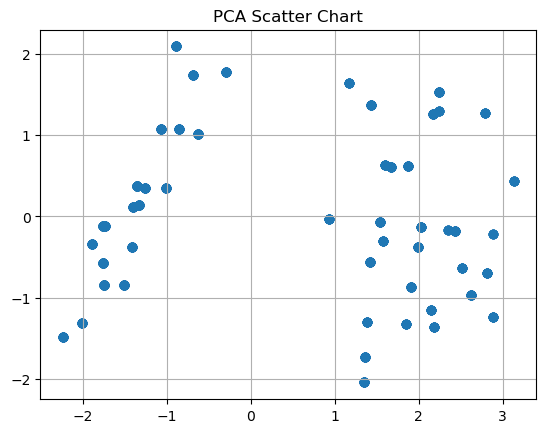

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.grid(True)
plt.title('PCA Scatter Chart')

# Results

- K-Means is an unsupervised learning algorithm that clusters given data into K different clusters.
- Elbow curve, or elbow curve clustering is finding the optimal K by finding for which K there exists an elbow in the K vs inertia plot.
- Silhouette plot is plotting K vs silhouette score for finding the maximum silhouette score and its corresponding K.
- PCA is a technique used to project multidimensional data to lesser dimensions.

### From all 3 plots, let the optimal cluster count be 2.